In [59]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [60]:
titolo = "Esperienza"
xlabel = "x"
ylabel = "y"

file_input = "dati.csv"
file_output = "residui.txt"
grafico_output1 = "grafico.pdf"
grafico_output2 = "residui.pdf"

### 1. Lettura

In [61]:
data = f.csv_to_dict(file_input)

### 2. Analisi

Regressione

In [62]:
xdata = np.array([data["x"],data["sx"]])
ydata = np.array([data["y"],data["sy"]])
def modello(par, x):
    return par[0] + par[1]*x

anal = f.fit(xdata,ydata,modello,[0,1])

Residui

In [63]:
f.inizializza_output(file_output)
res = f.residui(xdata,ydata,anal[:,0],modello,file_output,titolo)

### 3. Grafici

Regressione

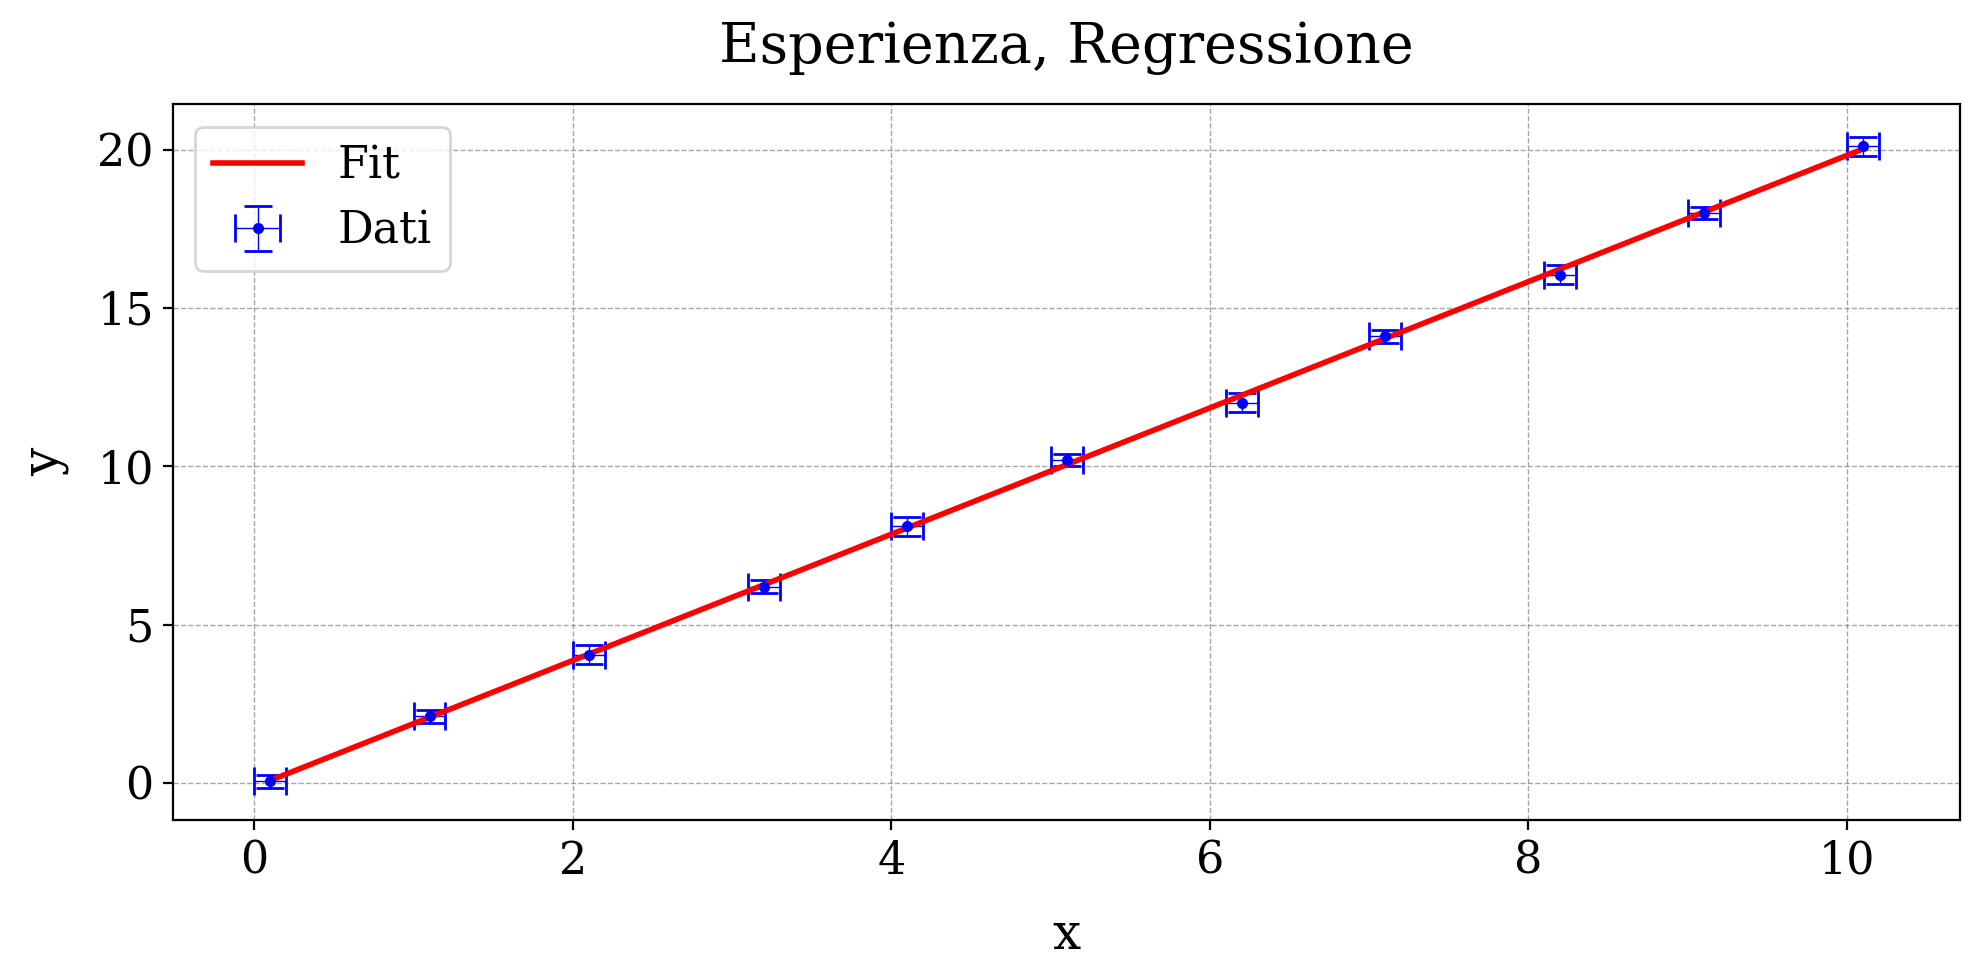

In [64]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Regressione",xlabel=xlabel,ylabel=ylabel)
# Grafico dei dati con errori
ax.errorbar(xdata[0],ydata[0],xerr=xdata[1],yerr=ydata[1],fmt=".",label="Dati",color="blue", **gf.default_error_params())
# Grafico del fit
x_fit = np.linspace(min(xdata[0]), max(xdata[0]), 500)
ax.plot(x_fit,modello(anal[:,0],x_fit),label="Fit",color="red")

ax.legend()

gf.salva_grafico(fig,grafico_output1)

Residui

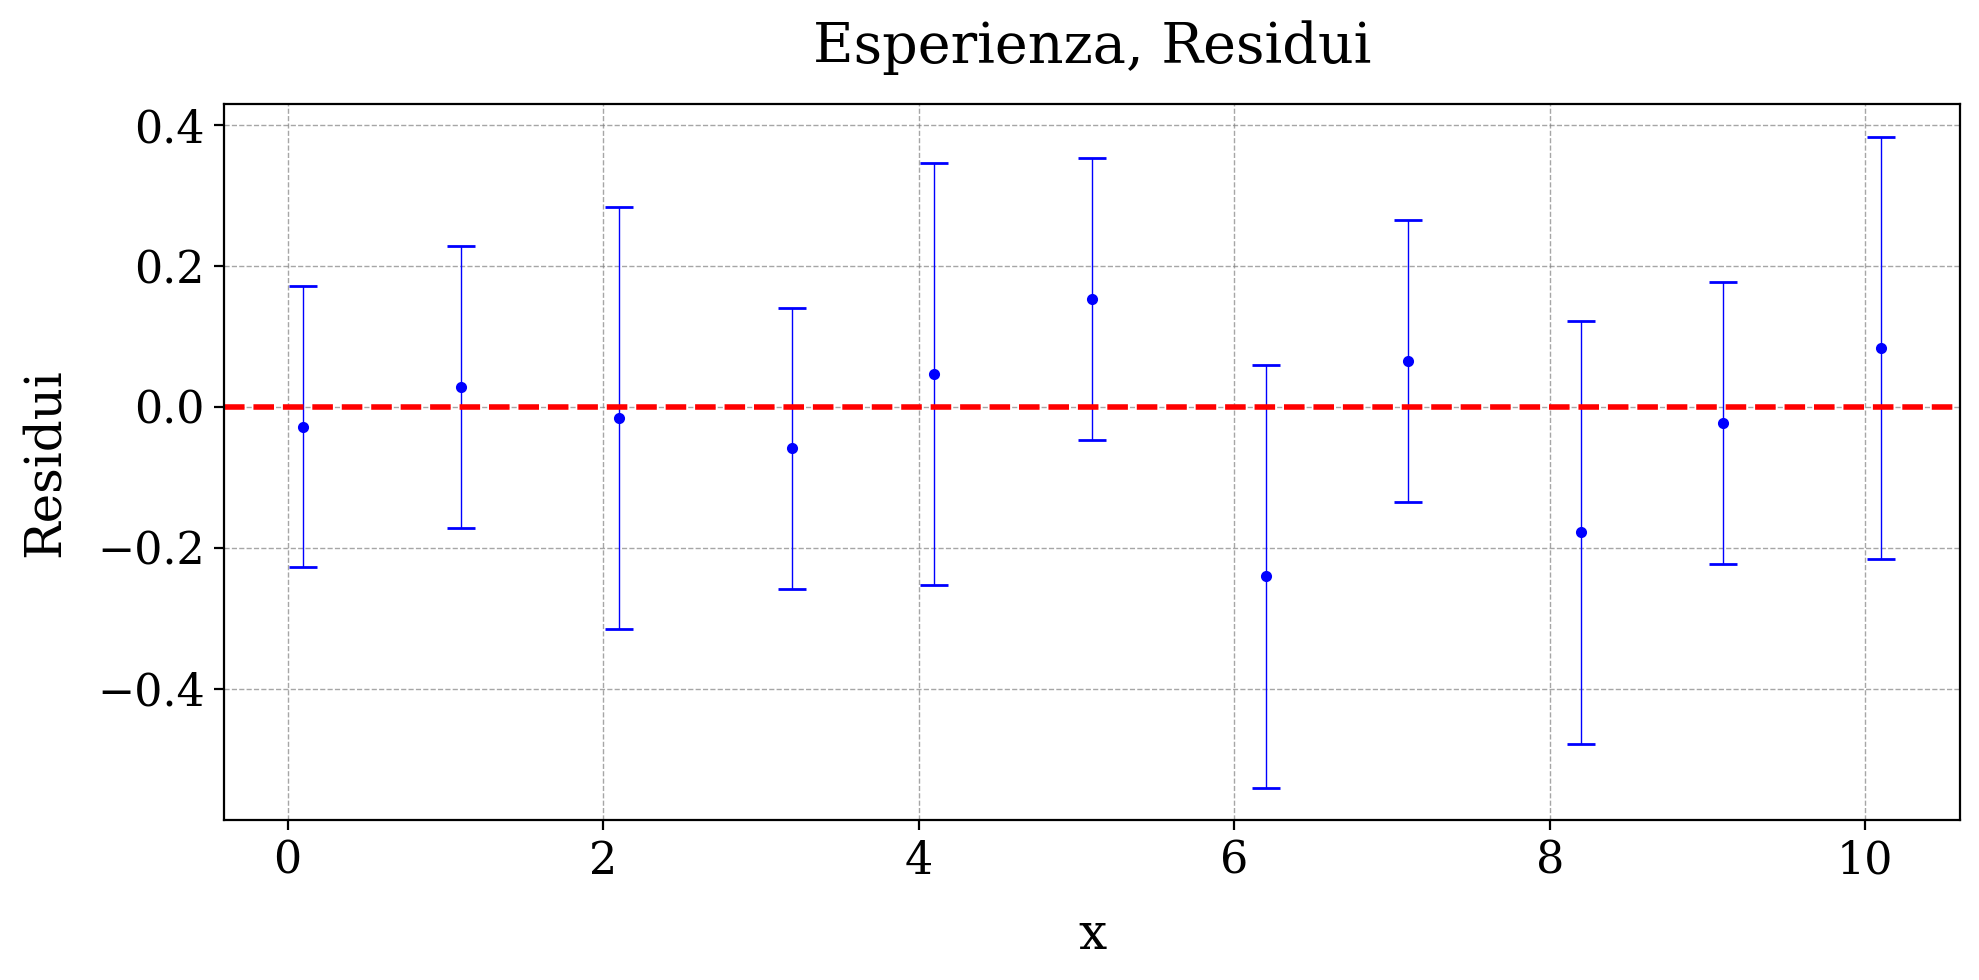

In [65]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Residui",xlabel=xlabel,ylabel="Residui")

ax.errorbar(res[0],res[1],yerr=res[2],fmt=".",color="blue", **gf.default_error_params())
ax.axhline(0, color="red", linestyle="--")

gf.salva_grafico(fig,grafico_output2)